This notebook presents human judgement scores from five Sesotho-proficient 
evaluators who rated 10 translations on Adequacy, Fluency, and Medical Accuracy, 
providing a qualitative complement to the automated metric results.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

## Load CSV & Inspect

In [2]:
df = pd.read_csv("human_eval_responses.csv")

print(f" Loaded {len(df)} evaluator responses")
print(f"\nTotal columns : {len(df.columns)}")
print(f"\nAll column names:")
for i, col in enumerate(df.columns):
    print(f"  [{i:02d}] '{col}'")

 Loaded 5 evaluator responses

Total columns : 34

All column names:
  [00] 'Timestamp'
  [01] 'Please rate each translation on three criteria using a 1–5 scale:'
  [02] 'What is your primary language?'
  [03] 'Q2.  How would you rate your Sesotho proficiency?'
  [04] 'Q3.  What is your professional background? (Select all that apply)'
  [05] 'Adequacy'
  [06] 'Fluency'
  [07] 'Adequacy.1'
  [08] 'Fluency.1'
  [09] 'Medical Accuracy'
  [10] 'Adequacy.2'
  [11] 'Fluency.2'
  [12] 'Medical Accuracy.1'
  [13] ' Adequacy'
  [14] 'Fluency.3'
  [15] ' Medical Accuracy'
  [16] 'Adequacy.3'
  [17] 'Fluency.4'
  [18] 'Medical Accuracy.2'
  [19] 'Adequacy.4'
  [20] 'Fluency.5'
  [21] 'Medical Accuracy.3'
  [22] ' Adequacy.1'
  [23] 'Fluency.6'
  [24] 'Medical Accuracy.4'
  [25] 'Adequacy.5'
  [26] 'Fluency.7'
  [27] 'Medical Accuracy.5'
  [28] 'Adequacy.6'
  [29] 'Fluency.8'
  [30] ' Medical Accuracy.1'
  [31] ' Adequacy.2'
  [32] 'Fluency.9'
  [33] 'Medical Accuracy.6'


## Robust Position-Based Column Rename

In [5]:
#  CONFIG 
METADATA_COLS = 5
SENTENCES     = 10
CRITERIA      = ["adequacy", "fluency", "medical_accuracy"]

#  EXPLICIT POSITION MAP (S1 medical_accuracy is missing from form export)
# Each tuple: (column_index, sentence_number, criterion)
position_map = [
    (5,  1, "adequacy"),
    (6,  1, "fluency"),
    # S1 medical_accuracy — NOT present in CSV export
    (7,  2, "adequacy"),
    (8,  2, "fluency"),
    (9,  2, "medical_accuracy"),
    (10, 3, "adequacy"),
    (11, 3, "fluency"),
    (12, 3, "medical_accuracy"),
    (13, 4, "adequacy"),
    (14, 4, "fluency"),
    (15, 4, "medical_accuracy"),
    (16, 5, "adequacy"),
    (17, 5, "fluency"),
    (18, 5, "medical_accuracy"),
    (19, 6, "adequacy"),
    (20, 6, "fluency"),
    (21, 6, "medical_accuracy"),
    (22, 7, "adequacy"),
    (23, 7, "fluency"),
    (24, 7, "medical_accuracy"),
    (25, 8, "adequacy"),
    (26, 8, "fluency"),
    (27, 8, "medical_accuracy"),
    (28, 9, "adequacy"),
    (29, 9, "fluency"),
    (30, 9, "medical_accuracy"),
    (31, 10, "adequacy"),
    (32, 10, "fluency"),
    (33, 10, "medical_accuracy"),
]

#  RENAME 
rename_map = {}
for pos, sentence, criterion in position_map:
    old_name = df.columns[pos]
    new_name = f"s{sentence}_{criterion}"
    rename_map[old_name] = new_name
    print(f"  [{pos:02d}] '{old_name}'  →  '{new_name}'")

df = df.rename(columns=rename_map)

renamed = [c for c in df.columns if c.startswith("s") and "_" in c]
print(f"\n Renamed {len(renamed)} score columns (29 present, s1_medical_accuracy absent).")


  [05] 'Adequacy'  →  's1_adequacy'
  [06] 'Fluency'  →  's1_fluency'
  [07] 'Adequacy.1'  →  's2_adequacy'
  [08] 'Fluency.1'  →  's2_fluency'
  [09] 'Medical Accuracy'  →  's2_medical_accuracy'
  [10] 'Adequacy.2'  →  's3_adequacy'
  [11] 'Fluency.2'  →  's3_fluency'
  [12] 'Medical Accuracy.1'  →  's3_medical_accuracy'
  [13] ' Adequacy'  →  's4_adequacy'
  [14] 'Fluency.3'  →  's4_fluency'
  [15] ' Medical Accuracy'  →  's4_medical_accuracy'
  [16] 'Adequacy.3'  →  's5_adequacy'
  [17] 'Fluency.4'  →  's5_fluency'
  [18] 'Medical Accuracy.2'  →  's5_medical_accuracy'
  [19] 'Adequacy.4'  →  's6_adequacy'
  [20] 'Fluency.5'  →  's6_fluency'
  [21] 'Medical Accuracy.3'  →  's6_medical_accuracy'
  [22] ' Adequacy.1'  →  's7_adequacy'
  [23] 'Fluency.6'  →  's7_fluency'
  [24] 'Medical Accuracy.4'  →  's7_medical_accuracy'
  [25] 'Adequacy.5'  →  's8_adequacy'
  [26] 'Fluency.7'  →  's8_fluency'
  [27] 'Medical Accuracy.5'  →  's8_medical_accuracy'
  [28] 'Adequacy.6'  →  's9_adequacy'

## Acknowledge the Missing Column

In [6]:
adequacy_cols = [f"s{i}_adequacy"         for i in range(1, 11)]
fluency_cols  = [f"s{i}_fluency"          for i in range(1, 11)]
accuracy_cols = [f"s{i}_medical_accuracy" for i in range(1, 11)]

# s1_medical_accuracy is absent from the CSV — remove it gracefully
adequacy_cols = [c for c in adequacy_cols if c in df.columns]
fluency_cols  = [c for c in fluency_cols  if c in df.columns]
accuracy_cols = [c for c in accuracy_cols if c in df.columns]

print(f"Adequacy columns  : {len(adequacy_cols)}  → {adequacy_cols}")
print(f"Fluency columns   : {len(fluency_cols)}  → {fluency_cols}")
print(f"Accuracy columns  : {len(accuracy_cols)}  (S1 missing from form export)")

missing = [f"s{i}_medical_accuracy" for i in range(1, 11)
           if f"s{i}_medical_accuracy" not in df.columns]
if missing:
    print(f"\n  Missing (excluded from analysis): {missing}")


Adequacy columns  : 10  → ['s1_adequacy', 's2_adequacy', 's3_adequacy', 's4_adequacy', 's5_adequacy', 's6_adequacy', 's7_adequacy', 's8_adequacy', 's9_adequacy', 's10_adequacy']
Fluency columns   : 10  → ['s1_fluency', 's2_fluency', 's3_fluency', 's4_fluency', 's5_fluency', 's6_fluency', 's7_fluency', 's8_fluency', 's9_fluency', 's10_fluency']
Accuracy columns  : 9  (S1 missing from form export)

  Missing (excluded from analysis): ['s1_medical_accuracy']


## Extract & Clean Scores

In [7]:
def extract_scores(df, cols):
    scores = df[cols].values.flatten().astype(float)
    return scores[~np.isnan(scores)]

adequacy_scores = extract_scores(df, adequacy_cols)
fluency_scores  = extract_scores(df, fluency_cols)
accuracy_scores = extract_scores(df, accuracy_cols)

print(f"   Adequacy ratings collected  : {len(adequacy_scores)}  (expected {len(df) * 10})")
print(f"   Fluency ratings collected   : {len(fluency_scores)}  (expected {len(df) * 10})")
print(f"   Accuracy ratings collected  : {len(accuracy_scores)}  (expected {len(df) * 10})")

criteria = {
    "Adequacy":         adequacy_scores,
    "Fluency":          fluency_scores,
    "Medical Accuracy": accuracy_scores,
}

   Adequacy ratings collected  : 50  (expected 50)
   Fluency ratings collected   : 50  (expected 50)
   Accuracy ratings collected  : 45  (expected 50)


## Summary Statistics Table

In [8]:
print("=" * 58)
print("   HUMAN EVALUATION — SUMMARY STATISTICS")
print("=" * 58)
print(f"  {'Criterion':<20} {'Mean':>6} {'SD':>6} {'Min':>5} {'Max':>5} {'N':>5}")
print("-" * 58)

for name, scores in criteria.items():
    s = scores.astype(float)
    print(f"  {name:<20} {np.mean(s):>6.2f} "
          f"{np.std(s):>6.2f} "
          f"{np.min(s):>5.0f} "
          f"{np.max(s):>5.0f} "
          f"{len(s):>5}")

print("=" * 58)
print(f"\n  Evaluators    : {len(df)}")
print(f"  Sentences     : {SENTENCES}")
print(f"  Total ratings : {len(df) * SENTENCES * len(CRITERIA)}")

   HUMAN EVALUATION — SUMMARY STATISTICS
  Criterion              Mean     SD   Min   Max     N
----------------------------------------------------------
  Adequacy               4.30   1.15     1     5    50
  Fluency                4.18   1.35     1     5    50
  Medical Accuracy       4.04   1.43     1     5    45

  Evaluators    : 5
  Sentences     : 10
  Total ratings : 150


## Figure 5: Bar Chart (Mean Scores per Criterion)

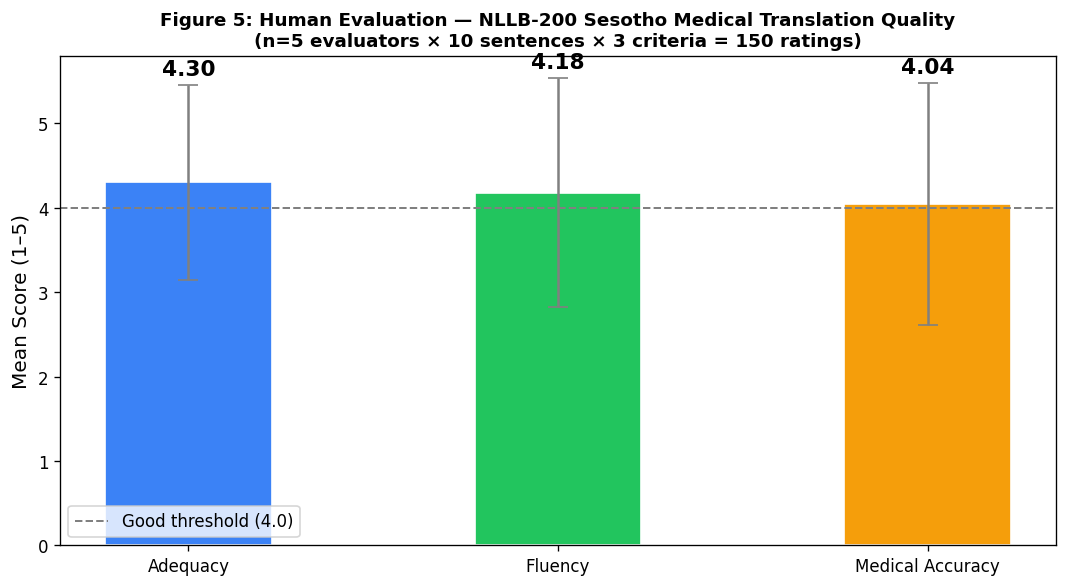

 Saved → figure5_human_evaluation.png


In [9]:
names  = list(criteria.keys())
means  = [np.mean(s.astype(float)) for s in criteria.values()]
stds   = [np.std(s.astype(float))  for s in criteria.values()]
colors = ["#3b82f6", "#22c55e", "#f59e0b"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    names, means,
    color=colors,
    edgecolor="white",
    width=0.45,
    yerr=stds,
    capsize=6,
    error_kw={"elinewidth": 1.5, "ecolor": "gray"}
)

ax.set_ylim(0, 5.8)
ax.axhline(y=4.0, color="gray", linestyle="--", linewidth=1.2, label="Good threshold (4.0)")
ax.set_ylabel("Mean Score (1–5)", fontsize=12)
ax.set_title(
    "Figure 5: Human Evaluation — NLLB-200 Sesotho Medical Translation Quality\n"
    f"(n={len(df)} evaluators × {SENTENCES} sentences × {len(CRITERIA)} criteria"
    f" = {len(df) * SENTENCES * len(CRITERIA)} ratings)",
    fontweight="bold", fontsize=11
)
ax.legend(fontsize=10)

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.12,
        f"{mean:.2f}",
        ha="center", fontweight="bold", fontsize=13
    )

plt.tight_layout()
plt.savefig("figure5_human_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → figure5_human_evaluation.png")


## Figure 6: Per-Sentence Line Chart

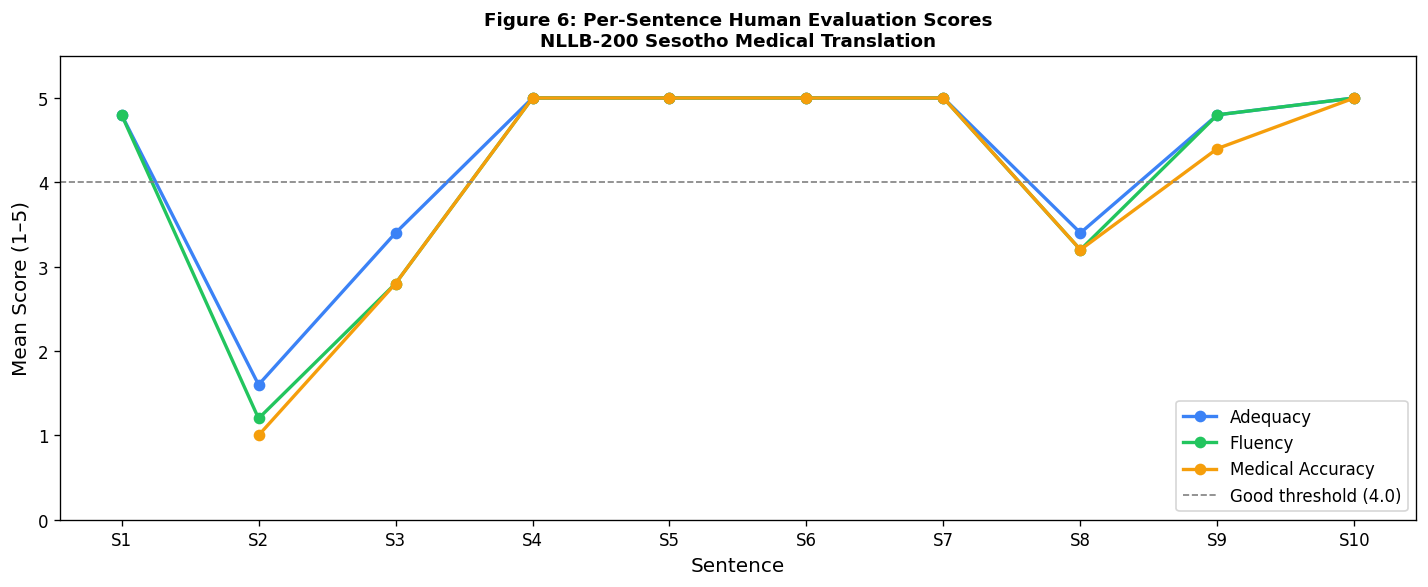

 Saved → figure6_per_sentence_scores.png


In [10]:
colors_line = {
    "Adequacy":         "#3b82f6",
    "Fluency":          "#22c55e",
    "Medical Accuracy": "#f59e0b",
}
col_keys = {
    "Adequacy":         "adequacy",
    "Fluency":          "fluency",
    "Medical Accuracy": "medical_accuracy",
}

fig, ax = plt.subplots(figsize=(12, 5))

for label, key in col_keys.items():
    cols  = [f"s{i}_{key}" for i in range(1, SENTENCES + 1)]
    cols  = [c for c in cols if c in df.columns]
    nums  = [int(c[1:].split("_")[0]) for c in cols]
    means_per_sentence = [df[c].astype(float).mean() for c in cols]

    ax.plot(
        nums,
        means_per_sentence,
        marker="o",
        linewidth=2,
        label=label,
        color=colors_line[label],
    )

ax.set_xticks(range(1, SENTENCES + 1))
ax.set_xticklabels([f"S{i}" for i in range(1, SENTENCES + 1)])
ax.set_ylim(0, 5.5)
ax.axhline(y=4.0, color="gray", linestyle="--", linewidth=1, label="Good threshold (4.0)")
ax.set_ylabel("Mean Score (1–5)", fontsize=12)
ax.set_xlabel("Sentence", fontsize=12)
ax.set_title(
    "Figure 6: Per-Sentence Human Evaluation Scores\n"
    "NLLB-200 Sesotho Medical Translation",
    fontweight="bold", fontsize=11
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("figure6_per_sentence_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → figure6_per_sentence_scores.png")


## Per-Sentence Breakdown Table

In [11]:
rows = []
for i in range(1, SENTENCES + 1):
    row = {"Sentence": f"S{i}"}
    for label, key in col_keys.items():
        col = f"s{i}_{key}"
        if col in df.columns:
            row[f"{label} Mean"] = round(df[col].astype(float).mean(), 2)
            row[f"{label} SD"]   = round(df[col].astype(float).std(),  2)
        else:
            row[f"{label} Mean"] = np.nan
            row[f"{label} SD"]   = np.nan
    rows.append(row)

breakdown = pd.DataFrame(rows)
print(breakdown.to_string(index=False))


Sentence  Adequacy Mean  Adequacy SD  Fluency Mean  Fluency SD  Medical Accuracy Mean  Medical Accuracy SD
      S1            4.8         0.45           4.8        0.45                    NaN                  NaN
      S2            1.6         0.55           1.2        0.45                    1.0                 0.00
      S3            3.4         0.55           2.8        1.30                    2.8                 1.10
      S4            5.0         0.00           5.0        0.00                    5.0                 0.00
      S5            5.0         0.00           5.0        0.00                    5.0                 0.00
      S6            5.0         0.00           5.0        0.00                    5.0                 0.00
      S7            5.0         0.00           5.0        0.00                    5.0                 0.00
      S8            3.4         0.89           3.2        0.84                    3.2                 0.84
      S9            4.8         0.45 

## Export Summary to CSV

In [12]:
summary = pd.DataFrame({
    "Criterion": list(criteria.keys()),
    "Mean":      [round(np.mean(s.astype(float)), 4) for s in criteria.values()],
    "Std Dev":   [round(np.std(s.astype(float)),  4) for s in criteria.values()],
    "Min":       [int(np.min(s.astype(float)))        for s in criteria.values()],
    "Max":       [int(np.max(s.astype(float)))        for s in criteria.values()],
    "N Ratings": [len(s)                              for s in criteria.values()],
})

summary.to_csv("human_eval_summary.csv", index=False)
print(" Saved → human_eval_summary.csv\n")
print(summary.to_string(index=False))


 Saved → human_eval_summary.csv

       Criterion   Mean  Std Dev  Min  Max  N Ratings
        Adequacy 4.3000   1.1533    1    5         50
         Fluency 4.1800   1.3519    1    5         50
Medical Accuracy 4.0444   1.4291    1    5         45
